In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

df1 = pd.read_excel('part1.xlsx')
df2 = pd.read_excel('part2.xlsx')

df = pd.concat([df1, df2], ignore_index=True)

print(df.shape)
df.head()

(367437, 24)


,restaurant_id,original_name,original_address,matched_name,google_id,matched_address,latitude,longitude,day,hour,...,weekday,demand_month,taxi_zone_id,taxi_zone_name,estimated_area_sqft,capacity,turnover_rate,takeaway_ratio,eat_in_ratio,dropoff_count
0,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,6,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,31.0
1,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,7,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,47.0
2,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,8,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,124.0
3,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,9,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,200.0
4,50142786,DA ANDREA RISTORANTE,"160 8 AVENUE, MANHATTAN, NY 10011",Da Andrea Chelsea,0x89c2593ba314c0d1:0xd5579301e987a1bd,NaN,40.742092,-74.000594,7,10,...,6,6,90,Flatiron,2143.2,117.876,1.0,0.1,0.9,249.0


In [2]:
import re
import numpy as np
import pandas as pd

def parse_typical_time(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip()

    # uniform sign
    x = x.replace("–", "-").replace("—", "-")

    pattern = r"""
        (?:
            spend\s+
        )?
        (\d+(?:\.\d+)?)                      # find the first figure
        \s*
        (min|mins|minute|minutes|hr|hrs|hour|hours)?   # first unit can be empty
        \s*
        (?:
            -|to
        )?
        \s*
        (?:
            (\d+(?:\.\d+)?)                  # second fighre
            \s*
            (min|mins|minute|minutes|hr|hrs|hour|hours)? # second unit
        )?
    """

    match = re.search(pattern, x, re.VERBOSE)

    if not match:
        return np.nan

    v1 = float(match.group(1))
    u1 = match.group(2)

    v2 = match.group(3)
    u2 = match.group(4)

    def normalize_unit(unit):
        if unit in ["hr", "hrs", "hour", "hours"]:
            return "hour"
        elif unit in ["min", "mins", "minute", "minutes"]:
            return "minute"
        return None

    u1 = normalize_unit(u1)
    u2 = normalize_unit(u2)

    # if one unit missing, assume two units are the same
    if v2 is not None:
        if u2 is None and u1 is not None:
            u2 = u1
        elif u1 is None and u2 is not None:
            u1 = u2

    if u1 is None:
        return np.nan

    def to_minutes(value, unit):
        if unit == "hour":
            return value * 60
        elif unit == "minute":
            return value
        return np.nan

    t1 = to_minutes(v1, u1)

    if v2 is not None:
        t2 = to_minutes(float(v2), u2)
        return (t1 + t2) / 2

    return t1


df["typical_time_mid"] = df["typical_time_spent"].apply(parse_typical_time)


In [3]:
df[["typical_time_spent","typical_time_mid"]].head(20)

,typical_time_spent,typical_time_mid
0,People typically spend 1.5-4 hours here,165.0
1,People typically spend 1.5-4 hours here,165.0
2,People typically spend 1.5-4 hours here,165.0
3,People typically spend 1.5-4 hours here,165.0
4,People typically spend 1.5-4 hours here,165.0
5,People typically spend 1.5-4 hours here,165.0
6,People typically spend 1.5-4 hours here,165.0
7,People typically spend 1.5-4 hours here,165.0
8,People typically spend 1.5-4 hours here,165.0
9,People typically spend 1.5-4 hours here,165.0


In [4]:
df["popularity"] = (
    df["rating"]
    * np.log1p(df["reviews"])
)

In [5]:
df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

In [6]:
df["friday"] = (df["day"]==5).astype(int)

df["saturday"] = (df["day"]==6).astype(int)

df["sunday"] = (df["day"]==7).astype(int)

In [7]:
df["ln_area"] = np.log(df["estimated_area_sqft"])

In [8]:
df["ln_dropoff"] = np.log1p(df["dropoff_count"])

In [9]:
df["ln_reviews"] = np.log1p(df["reviews"])

In [10]:
import pandas as pd

# ============================================
# 1. Define variables by observation level
# ============================================

# Hour-level variables:
# each restaurant can have multiple observations across different times
hourly_variables = [
    "busyness_score",
    "dropoff_count"
]

# Restaurant-level variables:
# values are constant within each restaurant_id
restaurant_variables = [
    "typical_time_mid",
    "rating",
    "reviews",
    "estimated_area_sqft",
    "capacity",
    "turnover_rate",
    "takeaway_ratio",
    "eat_in_ratio",
    "dropoff_count"
]


# ============================================
# 2. Prepare datasets
# ============================================

hourly_df = df[hourly_variables].copy()

restaurant_df = (
    df.groupby("restaurant_id", as_index=False)[restaurant_variables]
      .first()
)


# ============================================
# 3. Function for descriptive statistics
# ============================================

def calculate_descriptive_statistics(data, variables):
    results = {}

    for col in variables:
        # Convert to numeric in case the column contains strings
        full_series = pd.to_numeric(data[col], errors="coerce")
        valid_series = full_series.dropna()

        results[col] = {
            "N": valid_series.count(),
            "Missing": full_series.isna().sum(),
            "Mean": valid_series.mean(),
            "Std": valid_series.std(),
            "Min": valid_series.min(),
            "25%": valid_series.quantile(0.25),
            "50%": valid_series.quantile(0.50),
            "75%": valid_series.quantile(0.75),
            "Max": valid_series.max(),
            "Skewness": valid_series.skew(),
            "Kurtosis": valid_series.kurt()
        }

    return pd.DataFrame(results).T


# ============================================
# 4. Calculate statistics separately
# ============================================

hourly_summary = calculate_descriptive_statistics(
    hourly_df,
    hourly_variables
)

restaurant_summary = calculate_descriptive_statistics(
    restaurant_df,
    restaurant_variables
)


# ============================================
# 5. Combine into one table
# ============================================

summary = pd.concat([
    hourly_summary,
    restaurant_summary
])

# Keep N and Missing as integers
summary["N"] = summary["N"].astype(int)
summary["Missing"] = summary["Missing"].astype(int)

# Round continuous statistics
numeric_stat_columns = [
    "Mean",
    "Std",
    "Min",
    "25%",
    "50%",
    "75%",
    "Max",
    "Skewness",
    "Kurtosis"
]

summary[numeric_stat_columns] = (
    summary[numeric_stat_columns].round(3)
)

summary.index.name = "Variable"

display(summary)

,N,Missing,Mean,Std,Min,25%,50%,75%,Max,Skewness,Kurtosis
Variable,,,,,,,,,,,
busyness_score,367437,0,34.777,29.699,0.00,0.000,37.00,58.000,100.00,0.203,-1.170
dropoff_count,367435,2,527.305,423.824,1.00,184.000,428.00,794.000,2574.00,1.130,1.332
typical_time_mid,1741,1074,94.981,49.001,10.00,55.000,90.00,135.000,240.00,0.385,-0.275
rating,2814,1,4.316,0.401,1.40,4.100,4.40,4.600,5.00,-1.367,3.512
reviews,2814,1,1021.335,2287.693,2.00,213.250,495.00,1080.000,59998.00,13.594,282.889
estimated_area_sqft,2815,0,1934.174,1973.084,200.00,657.808,1197.45,2287.750,8000.00,1.846,2.710
capacity,2815,0,128.493,137.070,10.00,41.191,76.50,152.825,664.00,2.065,4.105
turnover_rate,2815,0,1.682,0.792,0.80,1.100,1.20,2.500,3.00,0.786,-1.057
takeaway_ratio,2815,0,0.357,0.240,0.05,0.200,0.20,0.600,0.80,0.593,-1.177


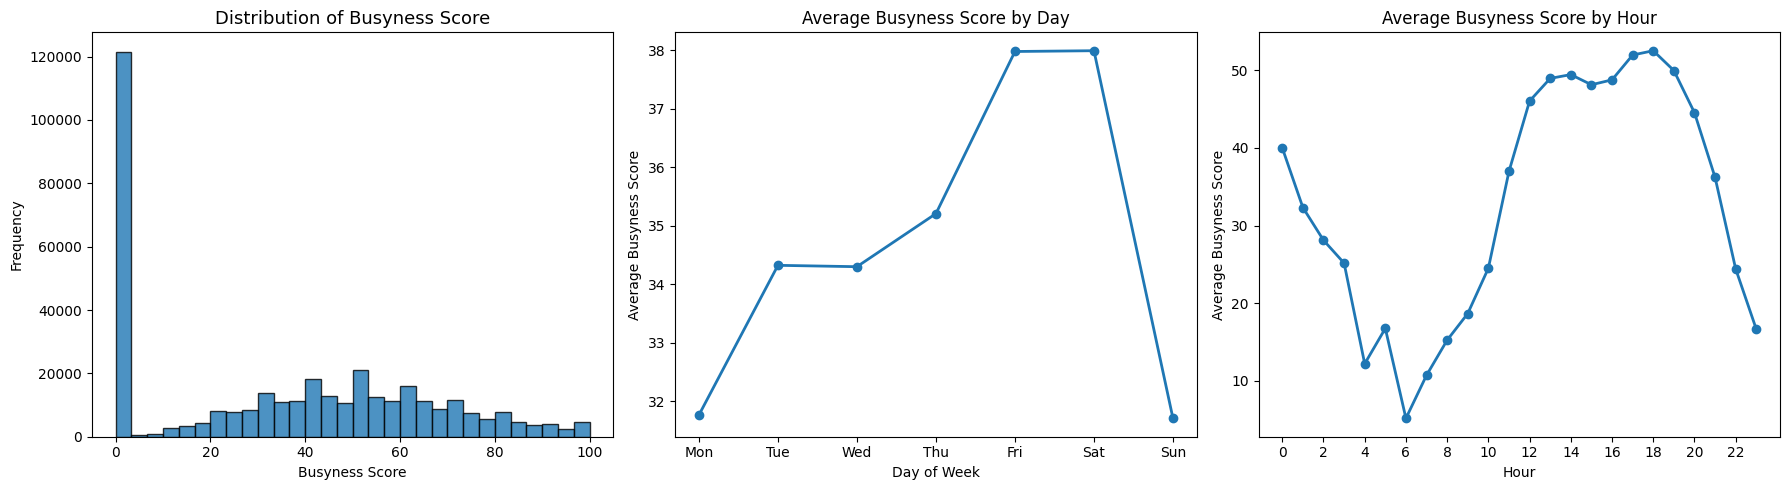

In [11]:
import matplotlib.pyplot as plt

# ============================================
# Descriptive Statistics
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# 1. Histogram of busyness_score
# -----------------------------
axes[0].hist(
    df["busyness_score"],
    bins=30,
    edgecolor="black",
    alpha=0.8
)
axes[0].set_title("Distribution of Busyness Score", fontsize=13)
axes[0].set_xlabel("Busyness Score")
axes[0].set_ylabel("Frequency")


# -----------------------------
# 2. Average busyness_score by day
# -----------------------------
day_avg = (
    df.groupby("day")["busyness_score"]
      .mean()
      .sort_index()
)

axes[1].plot(
    day_avg.index,
    day_avg.values,
    marker="o",
    linewidth=2
)

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(day_labels)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Busyness Score")
axes[1].set_title("Average Busyness Score by Day")


# -----------------------------
# 3. Average busyness_score by hour
# -----------------------------
hour_avg = (
    df.groupby("hour")["busyness_score"]
      .mean()
      .sort_index()
)

axes[2].plot(
    hour_avg.index,
    hour_avg.values,
    marker="o",
    linewidth=2
)

axes[2].set_xticks(range(0, 24, 2))
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Average Busyness Score")
axes[2].set_title("Average Busyness Score by Hour")


plt.tight_layout()
plt.show()

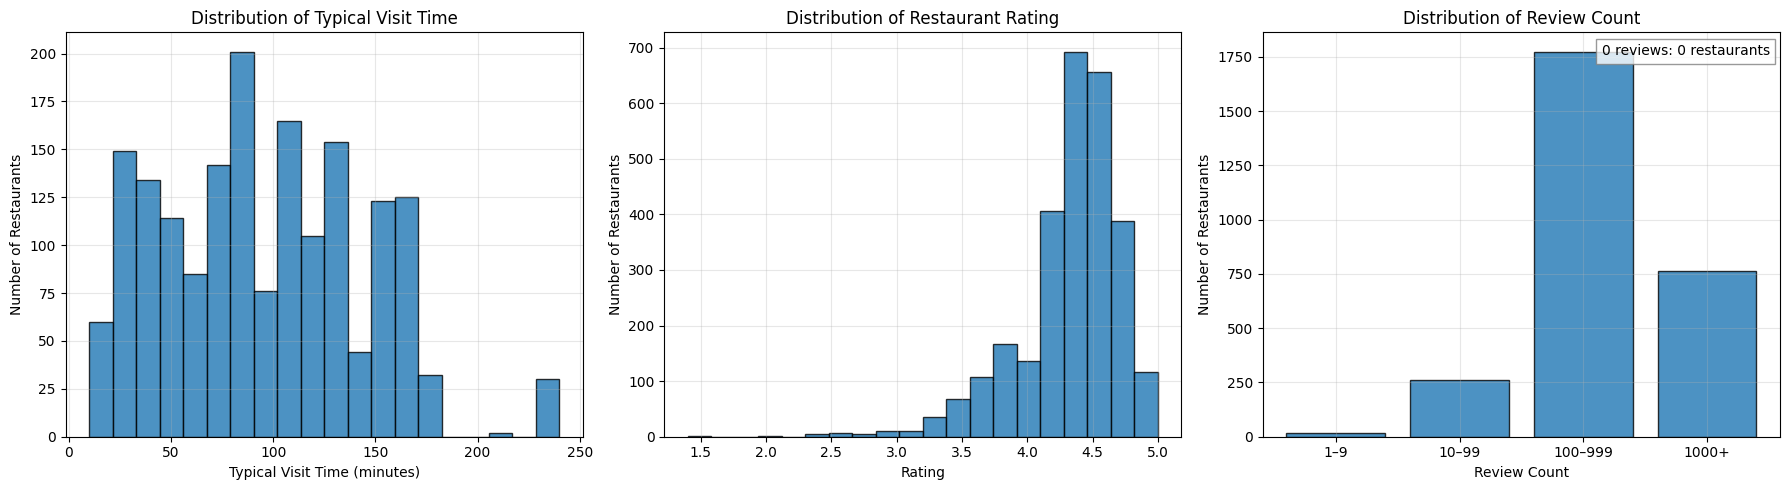

In [12]:
# ============================================
# Restaurant-level Features Distribution
# ============================================

restaurant_df = (
    df.groupby("restaurant_id", as_index=False)[
        ["typical_time_mid", "rating", "reviews"]
    ].first()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# Typical visit time
# -----------------------------
axes[0].hist(
    restaurant_df["typical_time_mid"].dropna(),
    bins=20,
    edgecolor="black",
    alpha=0.8
)
axes[0].set_title("Distribution of Typical Visit Time")
axes[0].set_xlabel("Typical Visit Time (minutes)")
axes[0].set_ylabel("Number of Restaurants")

# -----------------------------
# Rating
# -----------------------------
axes[1].hist(
    restaurant_df["rating"].dropna(),
    bins=20,
    edgecolor="black",
    alpha=0.8
)
axes[1].set_title("Distribution of Restaurant Rating")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of Restaurants")

# -----------------------------
# Review Count
# -----------------------------
review_all = restaurant_df["reviews"].dropna()

zero_count = (review_all == 0).sum()

review = review_all[review_all > 0]

review_group = pd.cut(
    review,
    bins=[0, 10, 100, 1000, float("inf")],
    labels=["1–9", "10–99", "100–999", "1000+"],
    right=False
)

review_counts = review_group.value_counts().sort_index()

axes[2].bar(
    review_counts.index.astype(str),
    review_counts.values,
    edgecolor="black",
    alpha=0.8
)

axes[2].set_title("Distribution of Review Count")
axes[2].set_xlabel("Review Count")
axes[2].set_ylabel("Number of Restaurants")
axes[2].grid(axis="y", alpha=0.3)

# Add annotation
axes[2].text(
    0.98, 0.97,
    f"0 reviews: {zero_count:,} restaurants",
    transform=axes[2].transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

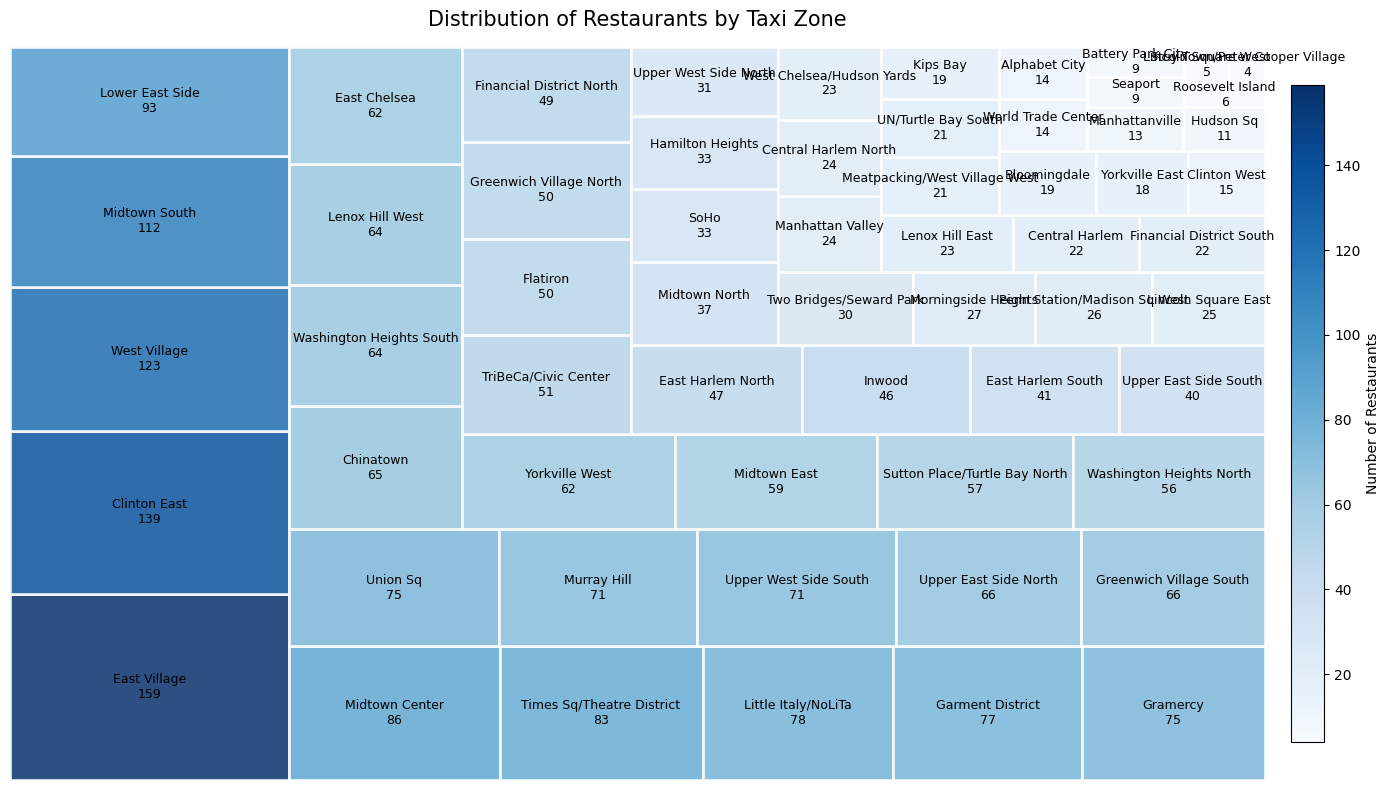

In [13]:
!pip install squarify
import matplotlib.colors as mcolors
import squarify

# ============================================
# Restaurant count by taxi zone
# ============================================

# each restaurant only keeps one record
restaurant_zone_df = (
    df.groupby("restaurant_id", as_index=False)["taxi_zone_name"]
      .first()
      .dropna(subset=["taxi_zone_name"])
)

# calculate the unique restaurant_id in each taxi zone
zone_counts = (
    restaurant_zone_df.groupby("taxi_zone_name")
                      .size()
                      .reset_index(name="restaurant_count")
                      .sort_values("restaurant_count", ascending=False)
)

# lables
labels = [
    f"{zone}\n{count:,}"
    for zone, count in zip(
        zone_counts["taxi_zone_name"],
        zone_counts["restaurant_count"]
    )
]

# depth = count of unique restaurant_id
norm = mcolors.Normalize(
    vmin=zone_counts["restaurant_count"].min(),
    vmax=zone_counts["restaurant_count"].max()
)

cmap = plt.cm.Blues

colors = [
    cmap(norm(count))
    for count in zone_counts["restaurant_count"]
]

# ============================================
# Draw treemap
# ============================================

fig, ax = plt.subplots(figsize=(14, 8))

squarify.plot(
    sizes=zone_counts["restaurant_count"],
    label=labels,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=2,
    ax=ax,
    text_kwargs={"fontsize": 9}
)

ax.set_title(
    "Distribution of Restaurants by Taxi Zone",
    fontsize=15,
    pad=15
)

ax.axis("off")

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Number of Restaurants")

plt.tight_layout()
plt.show()

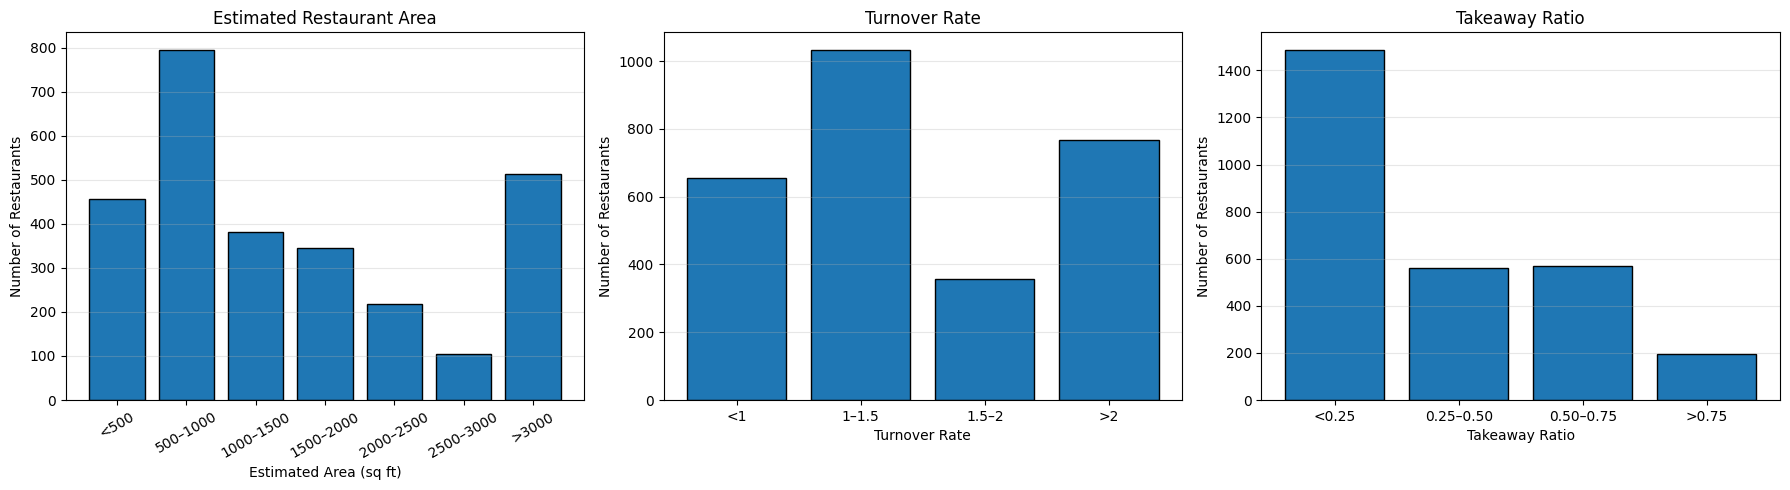

In [14]:
# ============================================
# Restaurant-level data
# ============================================

restaurant_df = (
    df.groupby("restaurant_id", as_index=False)[
        [
            "estimated_area_sqft",
            "turnover_rate",
            "takeaway_ratio"
        ]
    ].first()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ============================================
# Estimated Area
# ============================================

area_group = pd.cut(
    restaurant_df["estimated_area_sqft"],
    bins=[0, 500, 1000, 1500, 2000, 2500, 3000, float("inf")],
    labels=[
        "<500",
        "500–1000",
        "1000–1500",
        "1500–2000",
        "2000–2500",
        "2500–3000",
        ">3000"
    ],
    include_lowest=True
)

area_count = area_group.value_counts().sort_index()

axes[0].bar(
    area_count.index.astype(str),
    area_count.values,
    edgecolor="black"
)
axes[0].set_title("Estimated Restaurant Area")
axes[0].set_xlabel("Estimated Area (sq ft)")
axes[0].set_ylabel("Number of Restaurants")
axes[0].tick_params(axis='x', rotation=30)

# ============================================
# Turnover Rate
# ============================================

turnover_group = pd.cut(
    restaurant_df["turnover_rate"],
    bins=[0, 1, 1.5, 2, float("inf")],
    labels=[
        "<1",
        "1–1.5",
        "1.5–2",
        ">2"
    ],
    include_lowest=True
)

turnover_count = turnover_group.value_counts().sort_index()

axes[1].bar(
    turnover_count.index.astype(str),
    turnover_count.values,
    edgecolor="black"
)

axes[1].set_title("Turnover Rate")
axes[1].set_xlabel("Turnover Rate")
axes[1].set_ylabel("Number of Restaurants")

# ============================================
# Takeaway Ratio
# ============================================

takeaway_group = pd.cut(
    restaurant_df["takeaway_ratio"],
    bins=[0, 0.25, 0.5, 0.75, 1],
    labels=[
        "<0.25",
        "0.25–0.50",
        "0.50–0.75",
        ">0.75"
    ],
    include_lowest=True
)

takeaway_count = takeaway_group.value_counts().sort_index()

axes[2].bar(
    takeaway_count.index.astype(str),
    takeaway_count.values,
    edgecolor="black"
)

axes[2].set_title("Takeaway Ratio")
axes[2].set_xlabel("Takeaway Ratio")
axes[2].set_ylabel("Number of Restaurants")

# ============================================
# Beautify
# ============================================

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

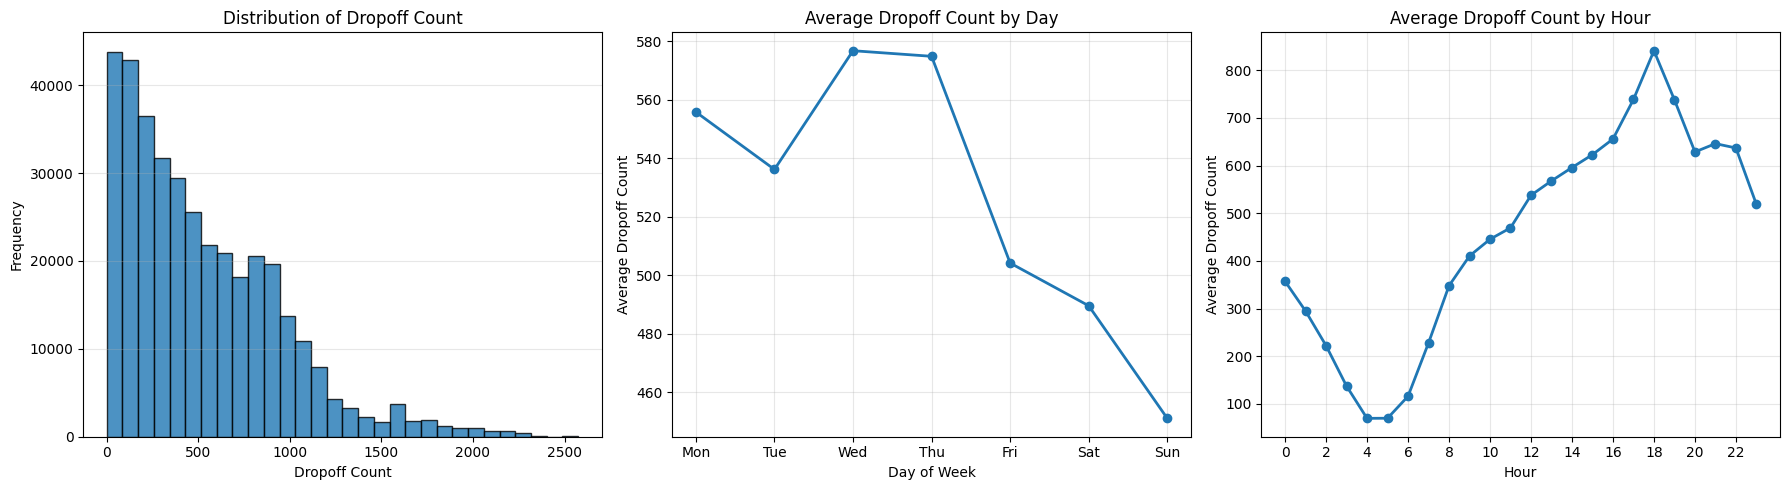

In [15]:
# ============================================
# Dropoff Count: Distribution, by Day, by Hour
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -----------------------------
# 1. Overall distribution
# -----------------------------
axes[0].hist(
    df["dropoff_count"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Dropoff Count")
axes[0].set_xlabel("Dropoff Count")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", alpha=0.3)


# -----------------------------
# 2. Average dropoff count by day
# -----------------------------
dropoff_by_day = (
    df.groupby("day")["dropoff_count"]
      .mean()
      .sort_index()
)

axes[1].plot(
    dropoff_by_day.index,
    dropoff_by_day.values,
    marker="o",
    linewidth=2
)

axes[1].set_title("Average Dropoff Count by Day")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Dropoff Count")
axes[1].grid(alpha=0.3)

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

axes[1].set_xticks(range(1, 8))
axes[1].set_xticklabels(day_labels)


# -----------------------------
# 3. Average dropoff count by hour
# -----------------------------
dropoff_by_hour = (
    df.groupby("hour")["dropoff_count"]
      .mean()
      .sort_index()
)

axes[2].plot(
    dropoff_by_hour.index,
    dropoff_by_hour.values,
    marker="o",
    linewidth=2
)

axes[2].set_title("Average Dropoff Count by Hour")
axes[2].set_xlabel("Hour")
axes[2].set_ylabel("Average Dropoff Count")
axes[2].set_xticks(range(0, 24, 2))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
restaurant_ids = df["restaurant_id"].unique()

print(len(restaurant_ids))

2815


In [17]:
train_restaurants = restaurant_ids[:2000]

test_restaurants = restaurant_ids[2000:]

In [18]:
train_df = df[df["restaurant_id"].isin(train_restaurants)].copy()

test_df = df[df["restaurant_id"].isin(test_restaurants)].copy()

print(train_df.shape)
print(test_df.shape)

(261500, 34)
(105937, 34)


In [19]:
train_zones = set(train_df["taxi_zone_id"].unique())
test_zones = set(test_df["taxi_zone_id"].unique())

missing_zones = test_zones - train_zones

print(f"Train taxi zones: {len(train_zones)}")
print(f"Test taxi zones : {len(test_zones)}")
print(f"Missing zones in train: {len(missing_zones)}")

if len(missing_zones) == 0:
    print("✓ All taxi zones in the test set are present in the training set.")
else:
    print("✗ Missing taxi zones:")
    print(sorted(missing_zones))

Train taxi zones: 60
Test taxi zones : 60
Missing zones in train: 0
✓ All taxi zones in the test set are present in the training set.


In [20]:
import statsmodels.api as sm

# ============================================
# 1. Numerical and categorical variables
# ============================================

feature_cols = [
    "hour_sin",
    "hour_cos",
    "friday",
    "saturday",
    "sunday",
    "typical_time_mid",
    "rating",
    "ln_reviews",
    "ln_area",
    "takeaway_ratio",
    "ln_dropoff"
]

categorical_cols = [
    "taxi_zone_id"
]

target_col = "busyness_score"

train_model_df = train_df[
    feature_cols + categorical_cols + [target_col]
].replace([np.inf, -np.inf], np.nan).dropna()

test_model_df = test_df[
    feature_cols + categorical_cols + [target_col]
].replace([np.inf, -np.inf], np.nan).dropna()

In [21]:
# ============================================
# 2. Construct train and test datasets
# ============================================

X_train = train_model_df[
    feature_cols + categorical_cols
].copy()

X_test = test_model_df[
    feature_cols + categorical_cols
].copy()

y_train = train_model_df[target_col].copy()
y_test = test_model_df[target_col].copy()

# Treat taxi_zone as a categorical variable
X_train["taxi_zone_id"] = X_train["taxi_zone_id"].astype(str)
X_test["taxi_zone_id"] = X_test["taxi_zone_id"].astype(str)

# ============================================
# 3. Check taxi-zone coverage
# ============================================

train_zones = set(X_train["taxi_zone_id"].dropna())
test_zones = set(X_test["taxi_zone_id"].dropna())

unseen_test_zones = test_zones - train_zones

print("Number of train zones:", len(train_zones))
print("Number of test zones:", len(test_zones))
print("Zones present in test but absent from train:", unseen_test_zones)

# ============================================
# 4. One-hot encode taxi-zone fixed effects
# ============================================

X_train = pd.get_dummies(
    X_train,
    columns=["taxi_zone_id"],
    prefix="taxi_zone_id",
    drop_first=True,
    dtype=float
)

X_test = pd.get_dummies(
    X_test,
    columns=["taxi_zone_id"],
    prefix="taxi_zone_id",
    drop_first=True,
    dtype=float
)

# Force test columns to match train columns
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Convert all explanatory variables to numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# ============================================
# 5. Handle missing or infinite values
# ============================================

train_valid = (
    X_train.notna().all(axis=1)
    & y_train.notna()
)

test_valid = (
    X_test.notna().all(axis=1)
    & y_test.notna()
)

X_train = X_train.loc[train_valid]
y_train = y_train.loc[train_valid]

X_test = X_test.loc[test_valid]
y_test = y_test.loc[test_valid]

# ============================================
# 6. Add intercept
# ============================================

X_train = sm.add_constant(
    X_train,
    has_constant="add"
)

X_test = sm.add_constant(
    X_test,
    has_constant="add"
)

# Ensure identical ordering
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# ============================================
# 7. Fit OLS
# ============================================

model = sm.OLS(
    y_train.astype(float),
    X_train.astype(float)
)

results = model.fit()

print(results.summary())

Number of train zones: 60
Number of test zones: 60
Zones present in test but absent from train: set()
                            OLS Regression Results                            
Dep. Variable:         busyness_score   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     1106.
Date:                Sun, 12 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:55:01   Log-Likelihood:            -7.3236e+05
No. Observations:              158108   AIC:                         1.465e+06
Df Residuals:                  158037   BIC:                         1.466e+06
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

train_pred = results.predict(X_train)
test_pred = results.predict(X_test)

print("Train")
print("R2 =", r2_score(y_train, train_pred))
print("MAE =", mean_absolute_error(y_train, train_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_train, train_pred)))

print()

print("Test")
print("R2 =", r2_score(y_test, test_pred))
print("MAE =", mean_absolute_error(y_test, test_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, test_pred)))

Train
R2 = 0.3288914450294478
MAE = 19.939171121270473
RMSE = 24.855758203841237

Test
R2 = 0.2902796549281431
MAE = 20.373680623086848
RMSE = 25.41118739821175


In [23]:
features = [
    "hour_sin",
    "hour_cos",
    "friday",
    "saturday",
    "sunday",
    "typical_time_mid",
    "rating",
    "ln_reviews",
    "ln_dropoff",
    "ln_area",
    "takeaway_ratio"
]

categories = [
    "taxi_zone_id"
]

In [24]:
X_train = train_model_df[features+categories]
y_train = train_model_df["busyness_score"]

X_test = test_model_df[features+categories]
y_test = test_model_df["busyness_score"]

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("Train")
print("R2 =", r2_score(y_train, train_pred))
print("MAE =", mean_absolute_error(y_train, train_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_train, train_pred)))

print()

print("Test")
print("R2 =", r2_score(y_test, test_pred))
print("MAE =", mean_absolute_error(y_test, test_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, test_pred)))

Train
R2 = 0.6603506979414999
MAE = 12.961309638267304
RMSE = 17.68259464103429

Test
R2 = 0.4510094977036426
MAE = 16.81634383392228
RMSE = 22.349290829862717


In [26]:
importance = (
    pd.Series(
        rf.feature_importances_,
        index=features + categories
    )
    .sort_values(ascending=False)
)

print(importance)

hour_sin            0.394499
hour_cos            0.180341
takeaway_ratio      0.129979
typical_time_mid    0.070405
ln_reviews          0.051961
ln_area             0.045724
rating              0.037977
ln_dropoff          0.032356
taxi_zone_id        0.030745
saturday            0.012876
friday              0.010010
sunday              0.003129
dtype: float64


In [27]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [28]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

train_pred = xgb.predict(X_train)
test_pred = xgb.predict(X_test)

In [29]:
print("Train")
print("R2 =", r2_score(y_train, train_pred))
print("MAE =", mean_absolute_error(y_train, train_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_train, train_pred)))

print()

print("Test")
print("R2 =", r2_score(y_test, test_pred))
print("MAE =", mean_absolute_error(y_test, test_pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, test_pred)))

Train
R2 = 0.7144839763641357
MAE = 12.142013549804688
RMSE = 16.212346512561325

Test
R2 = 0.47919005155563354
MAE = 16.573135375976562
RMSE = 21.768121996486197


In [30]:
importance = (
    pd.Series(
        xgb.feature_importances_,
        index=features + categories
    )
    .sort_values(ascending=False)
)

print(importance)

hour_sin            0.307749
takeaway_ratio      0.138352
hour_cos            0.137582
friday              0.076674
typical_time_mid    0.060915
saturday            0.060172
rating              0.044475
ln_dropoff          0.041740
ln_reviews          0.038084
taxi_zone_id        0.037971
ln_area             0.035720
sunday              0.020564
dtype: float32
